#Logistic Regression

###Introduction

Logistic Regression is a supervised machine learning algorithm used for classification tasks. It predicts the probability of an instance belonging to a specific class.

###Business Interest

The dataset contains credit card transactions, the need is for a model that can predict if a transaction is fraudulent (1) or not (0)

In [73]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.model_selection import train_test_split
#

### Understanding the data

In [74]:
credit_data=pd.read_csv('./creditcard.csv')

credit_data.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


The credit card transaction dataset is sourced from Kaggle and consists of labeled credit card transactions of European card holders in September 2013. 
According to the source, this dataset presents transactions that occurred in two days, where there were 492 frauds out of 284,807 transactions.
The dataset is highly unbalanced, the fraudulent class account for only 0.172% of all transactions.
The dataset contains 30 attributes, apart from the class which has values 1 in case of fraud and 0 otherwise. 
Due to confidentiality issues,28 features (V1-V28) in the dataset except Time and Amount were transformed using Principal Component Analysis.

### Identifying the target variable

In this case the target variable is 'class' and has binary values 0 (Genuine transaction) and 1 (Fradulent transaction)

### Data Cleaning and Feature Engineering

In [75]:
credit_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [76]:
print(credit_data.isnull().sum())

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64


There is no missing data 

Class
0    284315
1       492
Name: count, dtype: int64


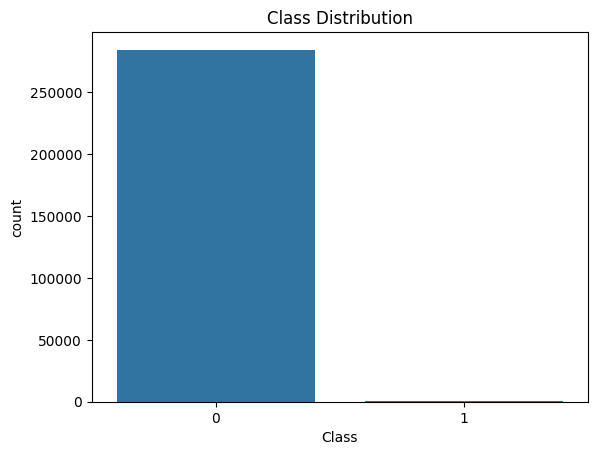

In [77]:
# Plot 'class' distribution

print(credit_data['Class'].value_counts()) 

sns.countplot(x=credit_data['Class'])
plt.title("Class Distribution")
plt.show()

This is an Imbalanced Dataset as the number of fraudulent transactions are very few compared to legitimate ones

In [78]:
credit_data.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [79]:
print(credit_data.shape)

(284807, 31)


In [80]:
#removing duplicate records

credit_data.drop_duplicates(subset=None, inplace=True)
print(credit_data.shape)

(283726, 31)


### Exploratory Data Analysis

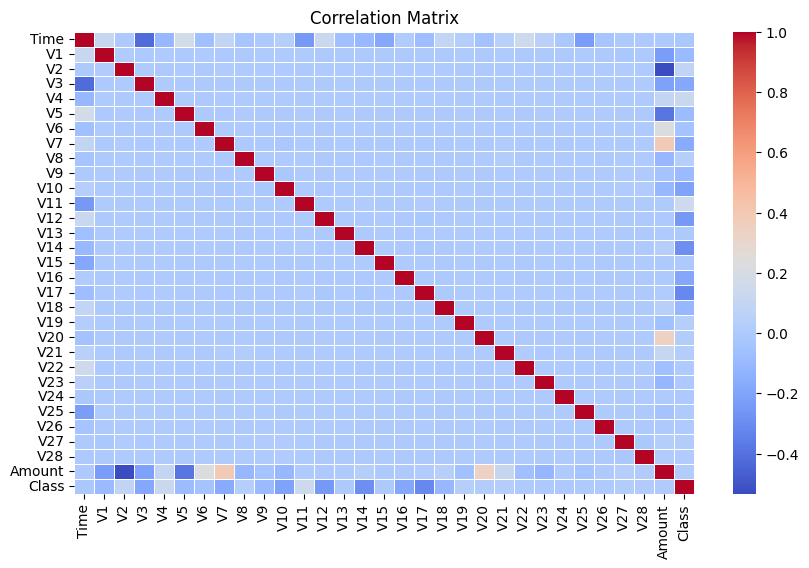

In [81]:
correlation_matrix = credit_data.corr()

# Visualize correlation matrix with a heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(correlation_matrix, annot=False, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix")
plt.show()

# note: A correlation matrix can only be used when all values are numeric

note for self: not using pairplot here because this dataset has a lot of attributes and so too many scatter plots takes significant memory and processing time, especially for large datasets.

### Feature Selection

Feature Influence Analysis (Using Logit Function)

Goal: Identify how each feature impacts the target variable.

In this case we are not splitting the data and instead using the entire dataset for this analysis. 

Method: Use statsmodels.Logit() to estimate coefficients and p-values.

Outputs:
P-values → Show if a feature significantly affects the target class.
Coefficients → Indicate whether a feature increases or decreases the likelihood of the event.
Confidence Intervals → Measure reliability of feature importance

In [82]:
X = credit_data.drop(columns=['Class'])  
y = credit_data['Class']

In [83]:
import statsmodels.api as sm   #pip3 install statsmodels

X_const = sm.add_constant(X)


logit_model = sm.Logit(y, X_const)
results = logit_model.fit()

# Display summary with p-values and coefficients
print(results.summary())

Optimization terminated successfully.
         Current function value: 0.003922
         Iterations 13
                           Logit Regression Results                           
Dep. Variable:                  Class   No. Observations:               283726
Model:                          Logit   Df Residuals:                   283695
Method:                           MLE   Df Model:                           30
Date:                Thu, 27 Feb 2025   Pseudo R-squ.:                  0.6819
Time:                        17:34:03   Log-Likelihood:                -1112.8
converged:                       True   LL-Null:                       -3498.2
Covariance Type:            nonrobust   LLR p-value:                     0.000
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -8.3983      0.250    -33.602      0.000      -8.888      -7.908
Time       -3.676e-06   2.26

Observation: Here we see that there are features whose p values are greater than 0.05 indicating that they are not significant for predicting the class.

📌 Hence we can use Backward Feature Elimination as a feature selection technique to improve the logistic regression model.

In [84]:


def backward_elimination(data_frame, dep_var, col_list, alpha=0.05):
    """
    Performs backward elimination and returns the final regression summary and remaining features.
    
    Parameters:
    - data_frame: DataFrame containing independent variables.
    - dep_var: Dependent variable (target).
    - col_list: List of column names (features).
    - alpha: Significance level threshold for p-value.
    
    Returns:
    - Final regression results
    - List of remaining features after backward elimination
    - List of removed features
    """
    removed_features = []  # Track removed features
    initial_features = col_list.copy()  # Save initial feature list
    
    while len(col_list) > 0:
        model = sm.Logit(dep_var, sm.add_constant(data_frame[col_list]))
        result = model.fit(disp=0)  # Suppress iteration output

        # Find the feature with the highest p-value
        max_pvalue = result.pvalues[1:].max()  # Ignore intercept (constant)
        
        if max_pvalue < alpha:  # Stop if all p-values are below alpha
            break
        else:
            col_to_remove = result.pvalues.idxmax()  # Get feature with highest p-value
            col_list.remove(col_to_remove)  # Remove from the feature list
            removed_features.append(col_to_remove)  # Track removed feature

    return result, col_list, removed_features

# Run backward elimination
initial_features = list(X.columns)  # Store original features
print("Initial Features:", initial_features)
final_result, remaining_features, removed_features = backward_elimination(X, y, initial_features)

# Print the results

print("Remaining Features After Backward Elimination:", remaining_features)
print("Removed Features:", removed_features)

# Display final model summary
print(final_result.summary())


Initial Features: ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount']
Remaining Features After Backward Elimination: ['V1', 'V4', 'V5', 'V7', 'V8', 'V9', 'V10', 'V13', 'V14', 'V16', 'V20', 'V21', 'V22', 'V23', 'V27', 'V28', 'Amount']
Removed Features: ['V26', 'V18', 'V3', 'V2', 'V17', 'V25', 'V11', 'V24', 'V12', 'V19', 'V15', 'Time', 'V6']
                           Logit Regression Results                           
Dep. Variable:                  Class   No. Observations:               283726
Model:                          Logit   Df Residuals:                   283708
Method:                           MLE   Df Model:                           17
Date:                Thu, 27 Feb 2025   Pseudo R-squ.:                  0.6804
Time:                        17:34:23   Log-Likelihood:                -1118.1
converged:                    

### Training model

 Predictive Modeling (Using LogisticRegression())

📌 Goal: Train a logistic regression model to make predictions and evaluate accuracy.
📌 Method: Use sklearn.LogisticRegression() to train and test the model.


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

X=X[remaining_features]

# Split into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Initialize and train logistic regression model
model = LogisticRegression()
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)



Model Accuracy: 1.00
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56656
           1       0.89      0.54      0.68        90

    accuracy                           1.00     56746
   macro avg       0.95      0.77      0.84     56746
weighted avg       1.00      1.00      1.00     56746



### Model Evaluation

In [90]:
# Evaluate model performance
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.2f}")
print(classification_report(y_test, y_pred))


Model Accuracy: 1.00
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56656
           1       0.89      0.54      0.68        90

    accuracy                           1.00     56746
   macro avg       0.95      0.77      0.84     56746
weighted avg       1.00      1.00      1.00     56746



note: However, accuracy can be misleading in cases of class imbalance 

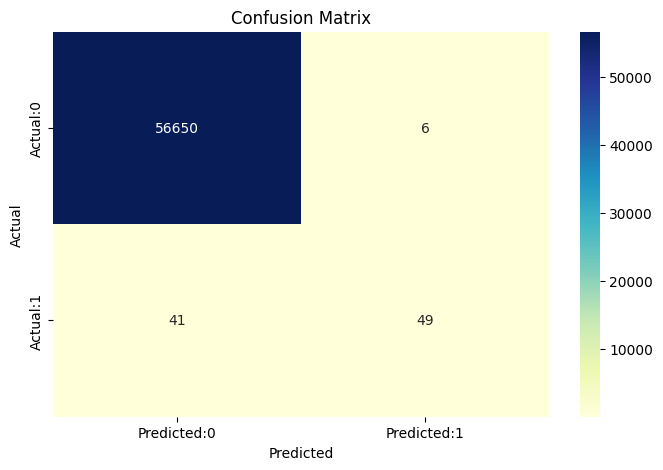

In [89]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

# Convert the confusion matrix to a DataFrame for better visualization
cm_df = pd.DataFrame(data=cm, columns=['Predicted:0', 'Predicted:1'], index=['Actual:0', 'Actual:1'])

# Plot the heatmap
plt.figure(figsize=(8, 5))
sns.heatmap(cm_df, annot=True, fmt='d', cmap="YlGnBu")
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

### Conclusion

The dataset is highly imbalanced and this model cannot be trusted.

Since this is credit card transaction data, resampling might not be the best idea.

### Further work

Adding weights to the minority class '1' can be another approch to solve the imbalanced data issue.

In [91]:
model_2 = LogisticRegression(class_weight='balanced')
model_2.fit(X_train, y_train)

y_pred = model_2.predict(X_test)

# Evaluate model performance
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.2f}")
print(classification_report(y_test, y_pred))


Model Accuracy: 0.97
              precision    recall  f1-score   support

           0       1.00      0.97      0.99     56656
           1       0.05      0.86      0.10        90

    accuracy                           0.97     56746
   macro avg       0.53      0.92      0.54     56746
weighted avg       1.00      0.97      0.99     56746



### Final Takeaway

The dataset was highly imbalanced
In this project, I evaluated the 